In [26]:
import torch as torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

from sklearn.preprocessing import StandardScaler

In [6]:
import sklearn
import platform
print(platform.system())
if platform.system()== 'Windows':
   sklearn.set_config(display='text')

Windows


In [7]:
# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

In [8]:
df = pd.read_csv('./credit.csv')

In [9]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

In [10]:
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(0)

In [11]:
df = df.drop('CUST_ID', axis = 1)

In [12]:
scaler = StandardScaler()

In [13]:
X = scaler.fit_transform(df)
X_tensor = torch.FloatTensor(X)

In [ ]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Linear(10, 3)
        )

        self.decoder = nn.Sequential(
            nn.Linear(3, 10),
            nn.ReLU(),
            nn.Linear(10, input_dim)
        )

    def forward(self, x):        
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = AutoEncoder(input_dim = X_tensor.shape[1])

In [18]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [31]:
epochs = 1000
losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = criterion(output, X_tensor)   # ★ y_train 대신 X_tensor 자기 자신과 비교!
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 100, Loss: 0.2036
Epoch 200, Loss: 0.2034
Epoch 300, Loss: 0.2033
Epoch 400, Loss: 0.2031
Epoch 500, Loss: 0.2030
Epoch 600, Loss: 0.2029
Epoch 700, Loss: 0.2027
Epoch 800, Loss: 0.2026
Epoch 900, Loss: 0.2023
Epoch 1000, Loss: 0.2020


In [21]:
model.eval()

with torch.no_grad() :
    compressed = model.encoder(X_tensor)

compressed_np = compressed.numpy()

In [25]:

kmeans = KMeans(n_clusters = 4, random_state = 42)
clusters = kmeans.fit_predict(compressed_np)

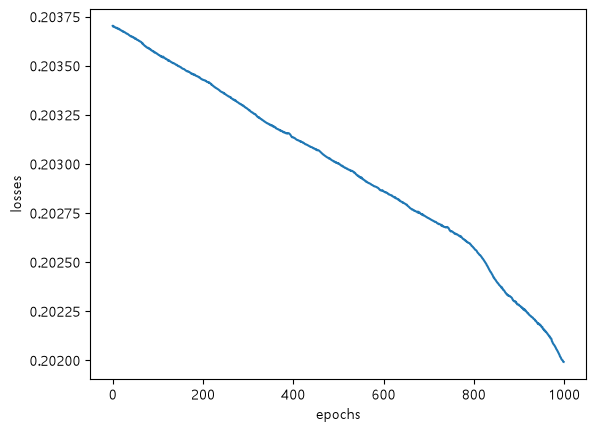

In [32]:
plt.plot(losses)
plt.xlabel('epochs'); plt.ylabel('losses')
plt.show()

In [34]:
model.eval()

with torch.no_grad() : 
    reconstructed = model(X_tensor)


compare = pd.DataFrame({
    'original' : X_tensor[0].numpy(),
    'reconstructed' : reconstructed[0].numpy()
})
print(compare)

    original  reconstructed
0  -0.731989      -0.407596
1  -0.249434      -0.525846
2  -0.424900      -0.384455
3  -0.356934      -0.273935
4  -0.349079      -0.407783
5  -0.466786      -0.434980
6  -0.806490      -0.833923
7  -0.678661      -0.509542
8  -0.707313      -0.674281
9  -0.675349      -0.292005
10 -0.476070      -0.372918
11 -0.511333      -0.504657
12 -0.960378      -0.428055
13 -0.528979      -0.436686
14 -0.297310      -0.225900
15 -0.525551      -0.433780
16  0.360680       0.535938


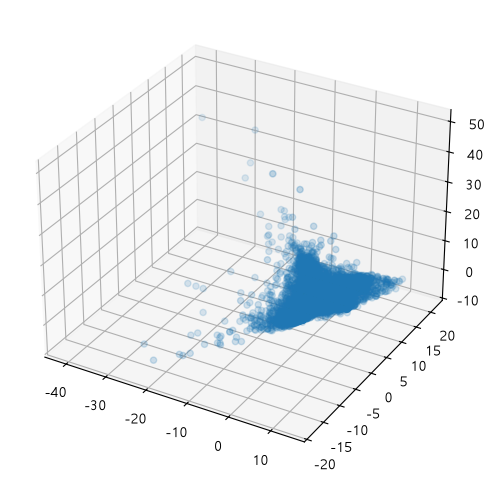

In [35]:
model.eval() 
with torch.no_grad() : 
    compressed = model.encoder(X_tensor).numpy()

fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(compressed[:, 0], compressed[:, 1], compressed[:, 2], alpha = 0.5) 
plt.show()

In [36]:
kmeans_compressed = KMeans(n_clusters = 4, random_state = 42)
clusters_compressed = kmeans_compressed.fit_predict(compressed)
score_compressed = silhouette_score(compressed, clusters_compressed)

kmenas_original = KMeans(n_clusters = 4, random_state = 42)
clusters_original = kmenas_original.fit_predict(X)
score_original = silhouette_score(X, clusters_original)

print(f"압축된 데이터 실루엣 점수: {score_compressed:.4f}")
print(f"원본 데이터 실루엣 점수: {score_original:.4f}")

압축된 데이터 실루엣 점수: 0.4338
원본 데이터 실루엣 점수: 0.1656
